In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Loading dataset
data = pd.read_csv('Housing.csv')

In [3]:
# Analyzing how many rows and columns are in dataset
data.shape

(545, 13)

In [4]:
#Seeing firt five rows of dataset
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [18]:
# Checking dataset information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [19]:
# Checking is their any duplicate values
data.duplicated().sum()

np.int64(0)

In [20]:
#checking is their any missing value
data.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [21]:
# Selecting all numeric columns
num_data = data.select_dtypes(include=[np.number])
print(num_data.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']


In [22]:
# Fetaure: X = all numeric values except exam_score
#        : y = exam_score [target_column]
X = num_data.drop(columns=['price'])
y = num_data['price']

In [ ]:
# Split data into 80% training and 20% testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Create LinearRegression = lr
lr = LinearRegression()
# Training the model
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 308.87, 151246.75,1185731.71, 495100.76, 337660.83]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['area','bedrooms','bathrooms','stories','parking']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.2e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [ ]:
# Predict Price
y_pred = lr.predict(X_test)

In [24]:
# Show how much each feature (area, bedrooms, etc.) affects the house price
coef_data = pd.DataFrame(lr.coef_, X.columns, columns=['Coefficient'])
print('\n Feature Coefficient')
print(coef_data)
print('\n Intercept: ', lr.intercept_)


 Feature Coefficient
            Coefficient
area       3.088670e+02
bedrooms   1.512468e+05
bathrooms  1.185732e+06
stories    4.951008e+05
parking    3.376608e+05

 Intercept:  51999.67680883687


In [ ]:
# Calulate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print('Model Evaluation Metrics')
print('MAE:      ', mae)
print('MSE:      ', mse)
print('RMSE:     ',rmse)
print('R2 Score: ',r2)


Model Evaluation Metrics
MAE:       1127483.3523235186
MSE:       2292721545725.3613
RMSE:      1514173.552049223
R2 Score:  0.5464062355495873


In [ ]:
# Creating Dataframe to compare actula and predicted prices
results_data = pd.DataFrame({'Actual Price': y_test.values, 'Predicted Price': y_pred})
results_data['Difference'] = results_data['Actual Price'] - results_data['Predicted Price']
print("\nPrediction Results (first 10 rows):")
print(results_data.head(10))


Prediction Results (first 10 rows):
   Actual Price  Predicted Price    Difference
0       4060000     6.178628e+06 -2.118628e+06
1       6650000     6.370141e+06  2.798591e+05
2       3710000     3.283148e+06  4.268518e+05
3       6440000     4.226008e+06  2.213992e+06
4       2800000     3.409686e+06 -6.096856e+05
5       4900000     4.262158e+06  6.378417e+05
6       5250000     5.493441e+06 -2.434405e+05
7       4543000     5.559898e+06 -1.016898e+06
8       2450000     3.373715e+06 -9.237154e+05
9       3353000     3.020513e+06  3.324868e+05


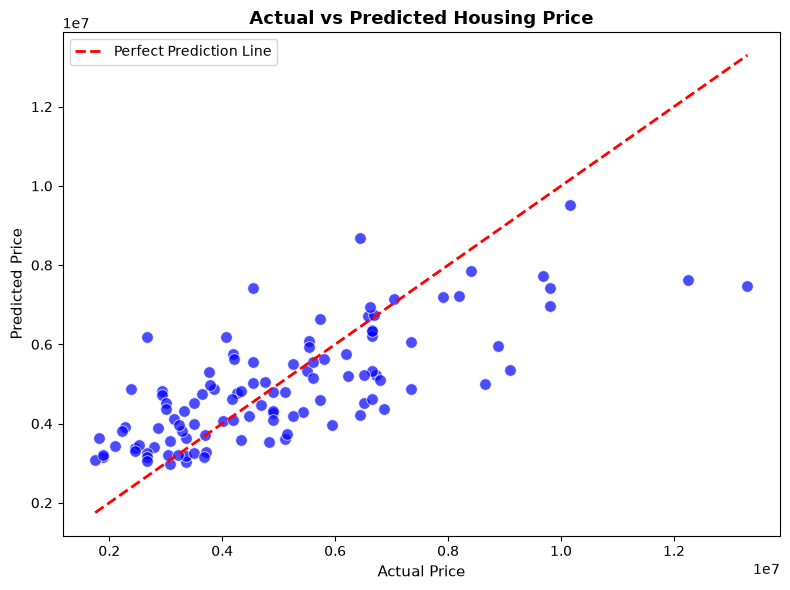

In [ ]:
# Plotting actual vs. predicted values to evaluate the model's prediction performance
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='b', edgecolor='white', s=70)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color="red", linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Price', fontsize=11)
plt.ylabel('Predicted Price', fontsize=11)
plt.title('Actual vs Predicted Housing Price', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()